# Review EmoDB and RAVDESS datasets

In [1]:
import kagglehub

ravdess_path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
emodb_path = kagglehub.dataset_download(
    "piyushagni5/berlin-database-of-emotional-speech-emodb"
)

print("Path to RAVDESS dataset files:", ravdess_path)
print("Path to EMO-DB dataset files:", emodb_path)

Path to RAVDESS dataset files: /Users/anhngo/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1
Path to EMO-DB dataset files: /Users/anhngo/.cache/kagglehub/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb/versions/1


In [101]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.model_selection import train_test_split
import ast
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# List RAVDESS files
ravdess_files = []
for root, dirs, files in os.walk(ravdess_path):
    for file in files:
        if file.endswith(".wav"):
            ravdess_files.append(os.path.join(root, file))

# List EmoDB files
emodb_files = []
for root, dirs, files in os.walk(emodb_path):
    for file in files:
        if file.endswith(".wav"):
            emodb_files.append(os.path.join(root, file))

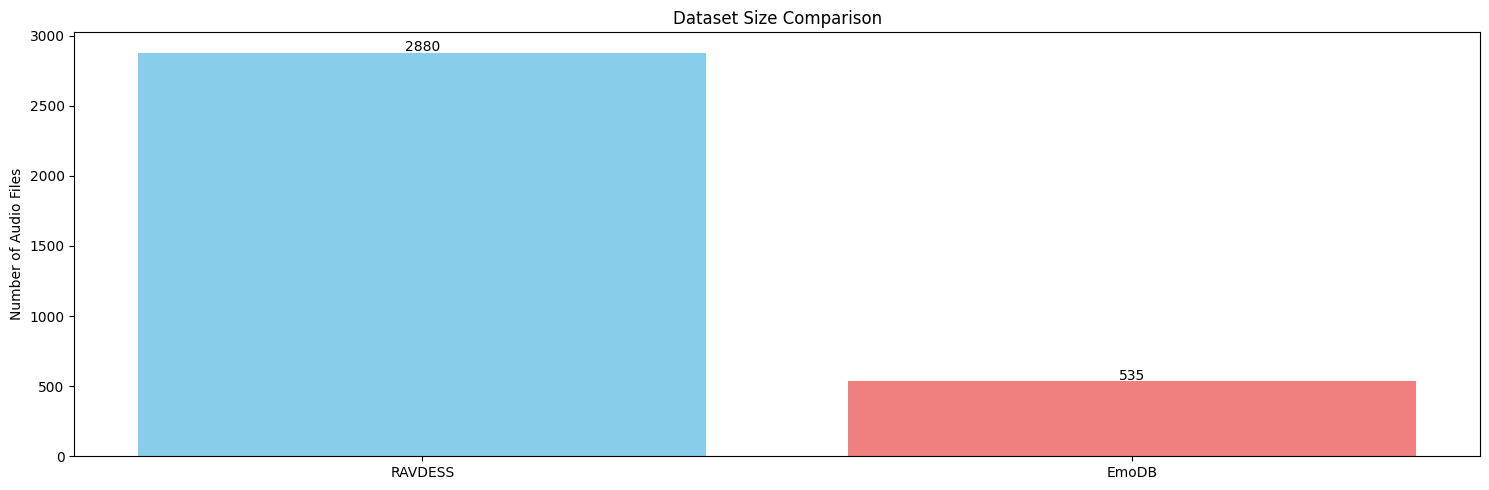

In [3]:
# Create a simple overview
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

# Dataset sizes
datasets = ["RAVDESS", "EmoDB"]
file_counts = [len(ravdess_files), len(emodb_files)]

axes.bar(datasets, file_counts, color=["skyblue", "lightcoral"])
axes.set_title("Dataset Size Comparison")
axes.set_ylabel("Number of Audio Files")
for i, v in enumerate(file_counts):
    axes.text(i, v + 10, str(v), ha="center")


plt.tight_layout()
plt.show()

## Emotion Analysis

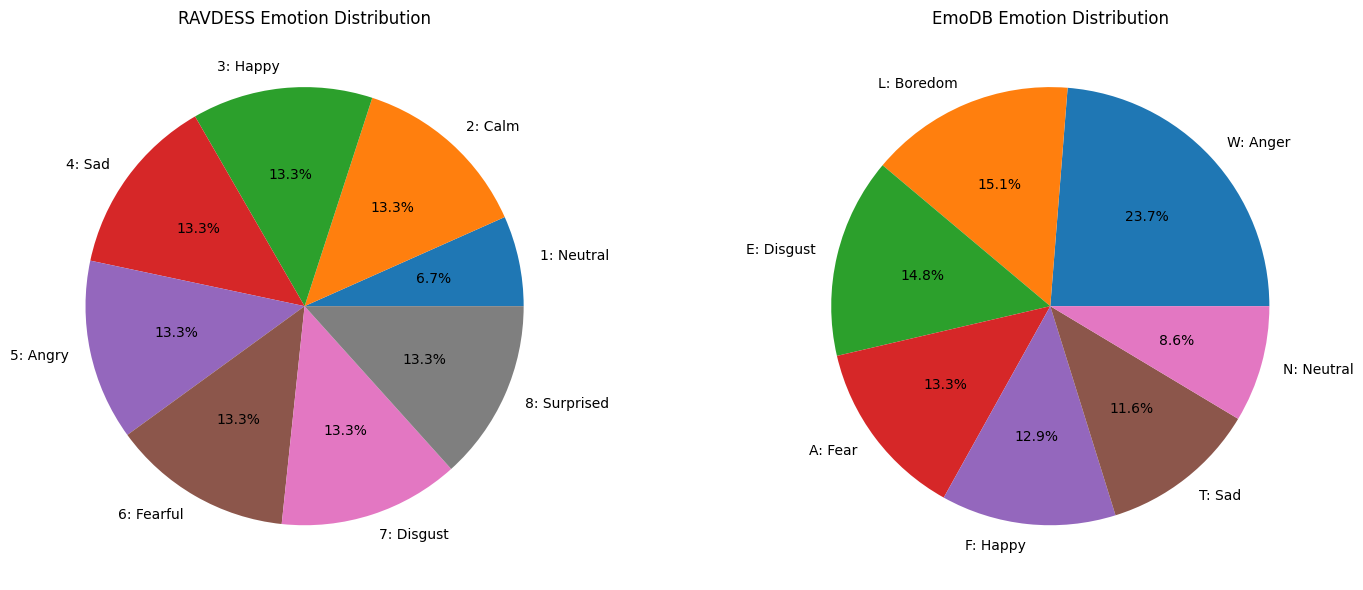

In [4]:
def parse_ravdess_emotions(files):
    """Extract emotions from RAVDESS filenames"""
    emotions = []
    for file in files:
        filename = os.path.basename(file)
        if filename.endswith(".wav"):
            emotion_code = filename.split("-")[2]
            emotions.append(emotion_code)
    return emotions


def parse_emodb_emotions(files):
    """Extract emotions from EmoDB filenames"""
    emotions = []
    for file in files:
        filename = os.path.basename(file)
        if filename.endswith(".wav"):
            emotion_code = filename[5]  # 6th character
            emotions.append(emotion_code)
    return emotions


# Parse emotions
ravdess_emotions = parse_ravdess_emotions(ravdess_files)
emodb_emotions = parse_emodb_emotions(emodb_files)

# Create emotion distribution plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RAVDESS emotions
ravdess_counts = pd.Series(ravdess_emotions).value_counts().sort_index()
ravdess_labels_reference = [
    "1: Neutral",
    "2: Calm",
    "3: Happy",
    "4: Sad",
    "5: Angry",
    "6: Fearful",
    "7: Disgust",
    "8: Surprised",
]

axes[0].pie(ravdess_counts.values, labels=ravdess_labels_reference, autopct="%1.1f%%")
axes[0].set_title("RAVDESS Emotion Distribution")

# EmoDB emotions
emodb_counts = pd.Series(emodb_emotions).value_counts()
emodb_labels_reference = [
    "W: Anger",
    "L: Boredom",
    "E: Disgust",
    "A: Fear",
    "F: Happy",
    "T: Sad",
    "N: Neutral",
]

axes[1].pie(emodb_counts.values, labels=emodb_labels_reference, autopct="%1.1f%%")
axes[1].set_title("EmoDB Emotion Distribution")

plt.tight_layout()
plt.show()

## Audio Duration Analysis


=== RAVDESS Audio Info ===
Average duration: 3.71s
Duration range: 3.20s - 4.64s


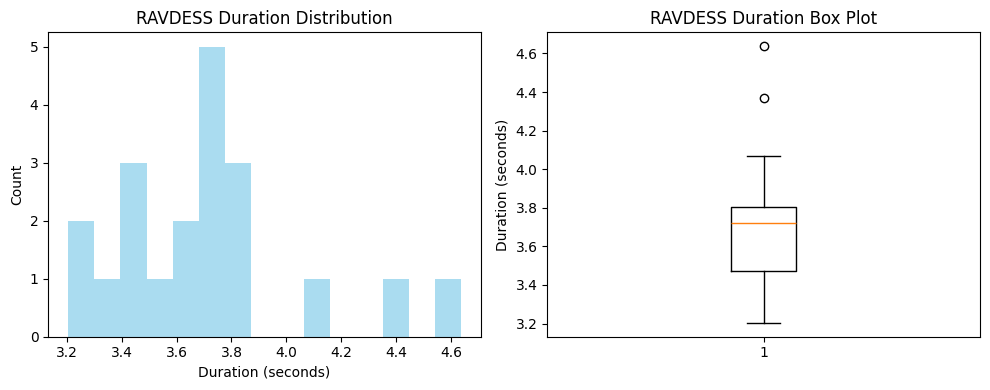


=== EmoDB Audio Info ===
Average duration: 2.64s
Duration range: 1.58s - 4.52s


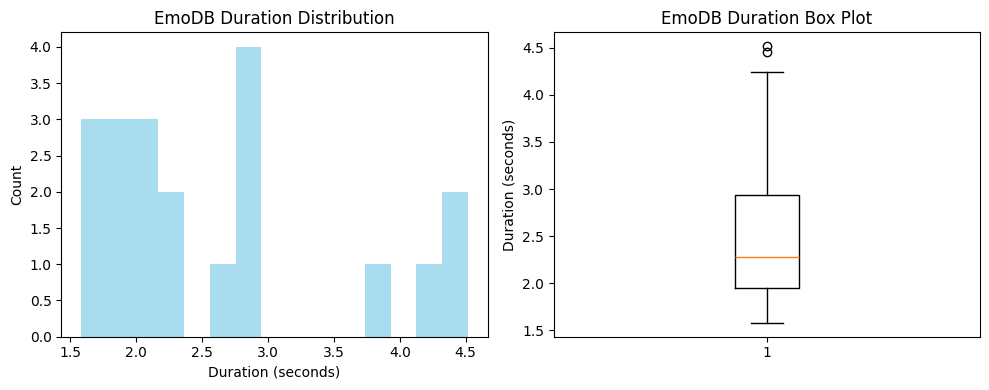

In [5]:
def get_audio_info(files, dataset_name, sample_size=20):
    """Get basic audio information"""
    print(f"\n=== {dataset_name} Audio Info ===")

    durations = []
    sample_files = np.random.choice(files, min(sample_size, len(files)), replace=False)

    for file in sample_files:
        try:
            y, sr = librosa.load(file, sr=None)
            duration = len(y) / sr
            durations.append(duration)
        except:
            continue

    if durations:
        print(f"Average duration: {np.mean(durations):.2f}s")
        print(f"Duration range: {np.min(durations):.2f}s - {np.max(durations):.2f}s")

        # Visualize durations
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.hist(durations, bins=15, alpha=0.7, color="skyblue")
        plt.title(f"{dataset_name} Duration Distribution")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Count")

        plt.subplot(1, 2, 2)
        plt.boxplot(durations)
        plt.title(f"{dataset_name} Duration Box Plot")
        plt.ylabel("Duration (seconds)")

        plt.tight_layout()
        plt.show()


# Analyze both datasets
get_audio_info(ravdess_files, "RAVDESS")
get_audio_info(emodb_files, "EmoDB")

# Organize and partition datasets into training, validation, and testing sets

## Create Dataset DataFrame

In [6]:
def create_dataset_df(files, dataset_name, emotion_code_pos):
    """Create DataFrame with file info and emotions"""
    data = []
    for file in files:
        filename = file.split("/")[-1]
        if dataset_name == "RAVDESS":
            # Format: 03-01-01-01-01-01-01.wav
            parts = filename.replace(".wav", "").split("-")
            emotion = parts[2]
            actor = parts[6]
        else:  # EmoDB
            # Format: 03a01Fa.wav
            emotion = filename.replace(".wav", "")[5]
            actor = filename.replace(".wav", "")[:2]

        data.append(
            {
                "filename": file,
                "dataset": dataset_name,
                "emotion": emotion,
                "actor": actor,
                "filepath": os.path.join(
                    ravdess_path if dataset_name == "RAVDESS" else emodb_path, file
                ),
            }
        )

    return pd.DataFrame(data)


# Create DataFrames
ravdess_df = create_dataset_df(ravdess_files, "RAVDESS", 2)
emodb_df = create_dataset_df(emodb_files, "EmoDB", 5)

print("RAVDESS DataFrame shape:", ravdess_df.shape)
print("EmoDB DataFrame shape:", emodb_df.shape)

print(ravdess_df.head())
print(emodb_df.head())

RAVDESS DataFrame shape: (2880, 5)
EmoDB DataFrame shape: (535, 5)
                                            filename  dataset emotion actor  \
0  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      05    16   
1  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      06    16   
2  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      06    16   
3  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      05    16   
4  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      07    16   

                                            filepath  
0  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
1  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
2  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
3  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
4  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
                                            filename dataset emotion actor  \
0  /Users/anhngo/.cache/kagglehub/datasets/piyush.

## Train-Validation-Test Split

In [7]:
def split_dataset(df, test_size=0.2, val_size=0.2, random_state=42):
    """Split dataset into train, validation, and test sets"""
    # Stratified split: Maintains emotion distribution across splits

    # First split: train+val vs test
    train_val, test = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df["emotion"]
    )

    # Second split: train vs val
    train, val = train_test_split(
        train_val,
        test_size=val_size / (1 - test_size),
        random_state=random_state,
        stratify=train_val["emotion"],
    )

    return train, val, test


# Split RAVDESS
ravdess_train, ravdess_val, ravdess_test = split_dataset(ravdess_df)

# Split EmoDB
emodb_train, emodb_val, emodb_test = split_dataset(
    emodb_df, test_size=0.1, val_size=0.1
)

print(
    f"RAVDESS - Train: {len(ravdess_train)}, Val: {len(ravdess_val)}, Test: {len(ravdess_test)}"
)
print(
    f"EmoDB - Train: {len(emodb_train)}, Val: {len(emodb_val)}, Test: {len(emodb_test)}"
)

RAVDESS - Train: 1728, Val: 576, Test: 576
EmoDB - Train: 427, Val: 54, Test: 54


## Save Split Information

In [8]:
# Save split information
def save_splits(train_df, val_df, test_df, dataset_name):
    """Save split information to CSV files"""
    train_df.to_csv(f"{dataset_name}_train.csv", index=False)
    val_df.to_csv(f"{dataset_name}_val.csv", index=False)
    test_df.to_csv(f"{dataset_name}_test.csv", index=False)
    print(f"{dataset_name} splits saved to CSV files")


# Save splits
save_splits(ravdess_train, ravdess_val, ravdess_test, "RAVDESS")
save_splits(emodb_train, emodb_val, emodb_test, "EmoDB")


print(ravdess_train.head())

RAVDESS splits saved to CSV files
EmoDB splits saved to CSV files
                                               filename  dataset emotion  \
480   /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      03   
2775  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      03   
2351  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      07   
1296  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      05   
217   /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  RAVDESS      06   

     actor                                           filepath  
480     04  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
2775    01  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
2351    24  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
1296    03  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  
217     20  /Users/anhngo/.cache/kagglehub/datasets/uwrfka...  


# Normalize and clean audio files.

In [9]:
# Load a sample file to test
sample_file = ravdess_files[0]
print(f"Sample file: {sample_file}")

Sample file: /Users/anhngo/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1/Actor_16/03-01-05-01-02-01-16.wav


In [10]:
def load_and_inspect_audio(file_path):
    """Load audio and show basic info"""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)

        print(f"Sample rate: {sr} Hz")
        print(f"Duration: {len(y)/sr:.2f} seconds")
        print(f"Audio range: {np.min(y):.3f} to {np.max(y):.3f}")
        print(f"Mean: {np.mean(y):.3f}")
        print(f"Std: {np.std(y):.3f}")

        return y, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None


# Test with sample file
y, sr = load_and_inspect_audio(sample_file)

Sample rate: 48000 Hz
Duration: 3.90 seconds
Audio range: -0.306 to 0.263
Mean: -0.000
Std: 0.020


## Audio Normalization

In [11]:
def normalize_audio(y):
    """Normalize audio with minmax"""
    # Scale to [-1, 1]
    y_norm = 2 * (y - np.min(y)) / (np.max(y) - np.min(y)) - 1

    return y_norm


# Test normalization methods
if y is not None:
    y_minmax = normalize_audio(y)

    print("\nNormalization results:")
    print(f"Original: [{np.min(y):.3f}, {np.max(y):.3f}]")
    print(f"Min-max: [{np.min(y_minmax):.3f}, {np.max(y_minmax):.3f}]")


Normalization results:
Original: [-0.306, 0.263]
Min-max: [-1.000, 1.000]


## Normalization Comparison

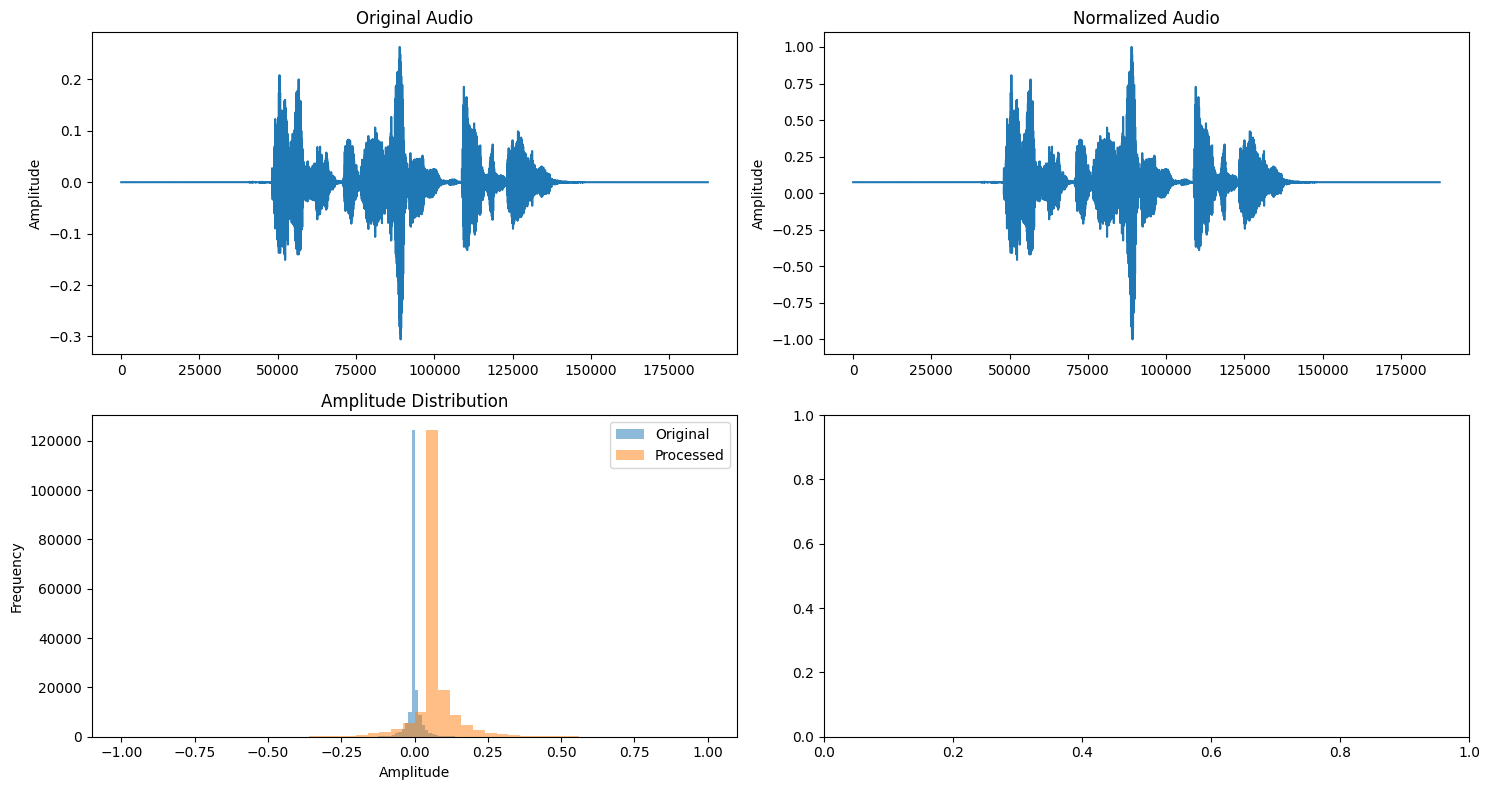

In [12]:
# Create visualization
if y is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Original audio
    axes[0, 0].plot(y)
    axes[0, 0].set_title("Original Audio")
    axes[0, 0].set_ylabel("Amplitude")

    # Normalized audio
    y_norm = normalize_audio(y)
    axes[0, 1].plot(y_norm)
    axes[0, 1].set_title("Normalized Audio")
    axes[0, 1].set_ylabel("Amplitude")

    # Histogram comparison
    axes[1, 0].hist(y, bins=50, alpha=0.5, label="Original")
    axes[1, 0].hist(y_norm, bins=50, alpha=0.5, label="Processed")
    axes[1, 0].set_title("Amplitude Distribution")
    axes[1, 0].set_xlabel("Amplitude")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].legend()

    plt.tight_layout()
    plt.show()

## Processing

In [13]:
def process_audio_file(input_path, output_path=None, target_sr=22050):
    """Process a single audio file"""
    try:
        # Load audio
        y, sr = librosa.load(input_path, sr=target_sr)

        # Normalize
        y_norm = normalize_audio(y)

        # Save if output path provided
        if output_path:
            # Use soundfile instead of librosa.output.write_wav
            import soundfile as sf

            sf.write(output_path, y_norm, target_sr)

        return y_norm, target_sr, True
    except Exception as e:
        print(f"Error processing {input_path}: {e}")
        return None, None, False


# Test processing
if ravdess_files:
    sample_file = ravdess_files[0]
    output_file = "sample_processed.wav"

    y_processed, sr_processed, success = process_audio_file(sample_file, output_file)

    if success:
        print(f"Processing successful!")
        print(f"Output saved to: {output_file}")
    else:
        print("Processing failed!")

Processing successful!
Output saved to: sample_processed.wav


### Processing all files

In [14]:
def batch_process_files(file_list, output_dir, max_files=10):
    """Process multiple audio files from existing file list"""
    os.makedirs(output_dir, exist_ok=True)

    # Limit files for testing
    files_to_process = file_list[:max_files]

    processed = 0
    failed = 0

    print(f"Processing {len(files_to_process)} files...")

    for file_path in files_to_process:
        filename = os.path.basename(file_path)
        output_path = os.path.join(output_dir, filename)

        success = process_audio_file(file_path, output_path)[2]

        if success:
            processed += 1
            print(f"✓ {filename}")
        else:
            failed += 1
            print(f"✗ {filename}")

    print(f"\nResults: {processed} processed, {failed} failed")
    return processed, failed


# Process RAVDESS files
print("Processing RAVDESS sample files...")
ravdess_processed, ravdess_failed = batch_process_files(
    ravdess_files, "processed_ravdess", max_files=len(ravdess_files)
)

# Process EmoDB files
print("\nProcessing EmoDB sample files...")
emodb_processed, emodb_failed = batch_process_files(
    emodb_files, "processed_emodb", max_files=len(emodb_files)
)

Processing RAVDESS sample files...
Processing 2880 files...
✓ 03-01-05-01-02-01-16.wav
✓ 03-01-06-01-02-02-16.wav
✓ 03-01-06-02-01-02-16.wav
✓ 03-01-05-02-01-01-16.wav
✓ 03-01-07-01-01-01-16.wav
✓ 03-01-04-01-01-02-16.wav
✓ 03-01-04-02-02-02-16.wav
✓ 03-01-07-02-02-01-16.wav
✓ 03-01-08-02-02-01-16.wav
✓ 03-01-08-01-01-01-16.wav
✓ 03-01-03-02-02-02-16.wav
✓ 03-01-03-01-01-02-16.wav
✓ 03-01-02-02-01-01-16.wav
✓ 03-01-01-01-02-02-16.wav
✓ 03-01-02-01-02-01-16.wav
✓ 03-01-03-02-01-01-16.wav
✓ 03-01-03-01-02-01-16.wav
✓ 03-01-02-02-02-02-16.wav
✓ 03-01-02-01-01-02-16.wav
✓ 03-01-01-01-01-01-16.wav
✓ 03-01-06-01-01-01-16.wav
✓ 03-01-05-01-01-02-16.wav
✓ 03-01-05-02-02-02-16.wav
✓ 03-01-06-02-02-01-16.wav
✓ 03-01-04-01-02-01-16.wav
✓ 03-01-07-01-02-02-16.wav
✓ 03-01-07-02-01-02-16.wav
✓ 03-01-04-02-01-01-16.wav
✓ 03-01-08-02-01-02-16.wav
✓ 03-01-08-01-02-02-16.wav
✓ 03-01-02-01-02-02-16.wav
✓ 03-01-01-01-02-01-16.wav
✓ 03-01-02-02-01-02-16.wav
✓ 03-01-03-01-01-01-16.wav
✓ 03-01-03-02-02-01-16

In [15]:
import pandas as pd
import os

# Load your existing splits
ravdess_train = pd.read_csv("RAVDESS_train.csv")
ravdess_val = pd.read_csv("RAVDESS_val.csv")
ravdess_test = pd.read_csv("RAVDESS_test.csv")

emodb_train = pd.read_csv("EmoDB_train.csv")
emodb_val = pd.read_csv("EmoDB_val.csv")
emodb_test = pd.read_csv("EmoDB_test.csv")

print("Original file paths:")
print(ravdess_train["filepath"].head())

Original file paths:
0    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
1    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
2    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
3    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
4    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
Name: filepath, dtype: object


In [16]:
import pandas as pd
import os

# Load the original CSV files
ravdess_train = pd.read_csv('RAVDESS_train.csv')
ravdess_val = pd.read_csv('RAVDESS_val.csv')
ravdess_test = pd.read_csv('RAVDESS_test.csv')

emodb_train = pd.read_csv('EmoDB_train.csv')
emodb_val = pd.read_csv('EmoDB_val.csv')
emodb_test = pd.read_csv('EmoDB_test.csv')

print("Original file paths:")
print(ravdess_train['filepath'].head())
print(emodb_train['filepath'].head())

Original file paths:
0    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
1    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
2    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
3    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
4    /Users/anhngo/.cache/kagglehub/datasets/uwrfka...
Name: filepath, dtype: object
0    /Users/anhngo/.cache/kagglehub/datasets/piyush...
1    /Users/anhngo/.cache/kagglehub/datasets/piyush...
2    /Users/anhngo/.cache/kagglehub/datasets/piyush...
3    /Users/anhngo/.cache/kagglehub/datasets/piyush...
4    /Users/anhngo/.cache/kagglehub/datasets/piyush...
Name: filepath, dtype: object


In [17]:
def fix_file_paths(df, dataset_name):
    """Fix file paths to point to processed files correctly"""
    df_fixed = df.copy()

    if dataset_name == "RAVDESS":
        # RAVDESS files are in processed_ravdess/ directly
        df_fixed["filepath"] = df_fixed["filepath"].apply(
            lambda x: f'processed_ravdess/{x.split("/")[-1]}'
        )
        df_fixed["filename"] = df_fixed["filename"].apply(lambda x: x.split("/")[-1])
    else:  # EmoDB
        # EmoDB files are in processed_emodb/ directly
        df_fixed["filepath"] = df_fixed["filename"].apply(
            lambda x: f'processed_emodb/{x.split("/")[-1]}'
        )
        df_fixed["filename"] = df_fixed["filename"].apply(lambda x: x.split("/")[-1])

    return df_fixed


# Fix RAVDESS files
ravdess_train_fixed = fix_file_paths(ravdess_train, "RAVDESS")
ravdess_val_fixed = fix_file_paths(ravdess_val, "RAVDESS")
ravdess_test_fixed = fix_file_paths(ravdess_test, "RAVDESS")

# Fix EmoDB files
emodb_train_fixed = fix_file_paths(emodb_train, "EmoDB")
emodb_val_fixed = fix_file_paths(emodb_val, "EmoDB")
emodb_test_fixed = fix_file_paths(emodb_test, "EmoDB")

print("Fixed file paths:")
print(ravdess_train_fixed[["filename", "filepath"]].head())
print(emodb_train_fixed[["filename", "filepath"]].head())

Fixed file paths:
                   filename                                    filepath
0  03-01-03-02-02-02-04.wav  processed_ravdess/03-01-03-02-02-02-04.wav
1  03-01-03-02-01-01-01.wav  processed_ravdess/03-01-03-02-01-01-01.wav
2  03-01-07-02-01-01-24.wav  processed_ravdess/03-01-07-02-01-01-24.wav
3  03-01-05-01-02-02-03.wav  processed_ravdess/03-01-05-01-02-02-03.wav
4  03-01-06-01-01-01-20.wav  processed_ravdess/03-01-06-01-01-01-20.wav
      filename                     filepath
0  14b09Ea.wav  processed_emodb/14b09Ea.wav
1  10b01Fa.wav  processed_emodb/10b01Fa.wav
2  11b10Td.wav  processed_emodb/11b10Td.wav
3  08a07Tb.wav  processed_emodb/08a07Tb.wav
4  09b03Ta.wav  processed_emodb/09b03Ta.wav


In [18]:
# Save the corrected files
ravdess_train_fixed.to_csv("RAVDESS_train_processed.csv", index=False)
ravdess_val_fixed.to_csv("RAVDESS_val_processed.csv", index=False)
ravdess_test_fixed.to_csv("RAVDESS_test_processed.csv", index=False)

emodb_train_fixed.to_csv("EmoDB_train_processed.csv", index=False)
emodb_val_fixed.to_csv("EmoDB_val_processed.csv", index=False)
emodb_test_fixed.to_csv("EmoDB_test_processed.csv", index=False)

print("Fixed CSV files saved!")

Fixed CSV files saved!


In [19]:
# Check if the files exist
sample_ravdess = ravdess_train_fixed['filepath'].iloc[0]
sample_emodb = emodb_train_fixed['filepath'].iloc[0]

print(f"RAVDESS sample file exists: {os.path.exists(sample_ravdess)}")
print(f"EmoDB sample file exists: {os.path.exists(sample_emodb)}")

print(f"\nRAVDESS sample path: {sample_ravdess}")
print(f"EmoDB sample path: {sample_emodb}")

RAVDESS sample file exists: True
EmoDB sample file exists: True

RAVDESS sample path: processed_ravdess/03-01-03-02-02-02-04.wav
EmoDB sample path: processed_emodb/14b09Ea.wav


# Extract features using Librosa.

In [20]:
ravdess_train = pd.read_csv("RAVDESS_train_processed.csv")
ravdess_val = pd.read_csv("RAVDESS_val_processed.csv")
ravdess_test = pd.read_csv("RAVDESS_test_processed.csv")

emodb_train = pd.read_csv("EmoDB_train_processed.csv")
emodb_val = pd.read_csv("EmoDB_val_processed.csv")
emodb_test = pd.read_csv("EmoDB_test_processed.csv")

print(f"RAVDESS train: {len(ravdess_train)} files")
print(f"EmoDB train: {len(emodb_train)} files")

RAVDESS train: 1728 files
EmoDB train: 427 files


In [21]:
def extract_features(file_path, sr=22050):
    """Extract audio features from a single file"""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=sr)

        # MFCC features
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)
        mfccs_std = np.std(mfccs, axis=1)

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)

        # Spectral features
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y)

        # Combine features
        features = np.concatenate(
            [
                mfccs_mean,  # 13 MFCC means
                mfccs_std,  # 13 MFCC stds
                chroma_mean,  # 12 chroma means
                chroma_std,  # 12 chroma stds
                [np.mean(spectral_centroids)],  # 1 spectral centroid mean
                [np.std(spectral_centroids)],  # 1 spectral centroid std
                [np.mean(spectral_rolloff)],  # 1 spectral rolloff mean
                [np.std(spectral_rolloff)],  # 1 spectral rolloff std
                [np.mean(zero_crossing_rate)],  # 1 ZCR mean
                [np.std(zero_crossing_rate)],  # 1 ZCR std
            ]
        )

        return features, True

    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None, False


# Test feature extraction
sample_file = ravdess_train["filepath"].iloc[0]
print(f"Testing feature extraction on: {sample_file}")

features, success = extract_features(sample_file)
if success:
    print(f"Features extracted successfully!")
    print(f"Feature vector shape: {features.shape}")
    print(f"Feature vector: {features[:10]}...")  # Show first 10 features
else:
    print("Feature extraction failed!")

Testing feature extraction on: processed_ravdess/03-01-03-02-02-02-04.wav
Features extracted successfully!
Feature vector shape: (56,)
Feature vector: [-375.19113159   33.67808151  -18.71838379    7.41590691   -2.53717828
   -6.60635853   -4.57060766  -11.39201927    1.2597127     1.04061639]...


In [22]:
def extract_features_batch(df, max_files=10):
    """Extract features from multiple files"""
    features_list = []
    labels_list = []
    file_paths = []

    # Limit files for testing
    files_to_process = df.head(max_files)

    print(f"Extracting features from {len(files_to_process)} files...")

    for i, row in files_to_process.iterrows():
        file_path = row["filepath"]
        emotion = row["emotion"]

        features, success = extract_features(file_path)

        if success:
            features_list.append(features)
            labels_list.append(emotion)
            file_paths.append(file_path)
            print(f"✓ {os.path.basename(file_path)}")
        else:
            print(f"✗ {os.path.basename(file_path)}")

    print(f"Extracted features from {len(features_list)} files successfully")
    print(f"Failed to extract features from {len(file_paths) - len(features_list)} files")
    return np.array(features_list), labels_list, file_paths


# Extract features from RAVDESS train
print("Extracting RAVDESS train features...")
ravdess_features, ravdess_labels, ravdess_paths = extract_features_batch(
    ravdess_train, max_files=len(ravdess_train)
)

# Extract features from EmoDB train
print("\nExtracting EmoDB train features...")
emodb_features, emodb_labels, emodb_paths = extract_features_batch(
    emodb_train, max_files=len(emodb_train)
)

Extracting RAVDESS train features...
Extracting features from 1728 files...
✓ 03-01-03-02-02-02-04.wav
✓ 03-01-03-02-01-01-01.wav
✓ 03-01-07-02-01-01-24.wav
✓ 03-01-05-01-02-02-03.wav
✓ 03-01-06-01-01-01-20.wav
✓ 03-01-06-02-01-01-24.wav
✓ 03-01-03-02-02-02-16.wav
✓ 03-01-08-01-02-02-22.wav
✓ 03-01-04-01-01-02-09.wav
✓ 03-01-07-02-02-01-01.wav
✓ 03-01-08-01-01-01-12.wav
✓ 03-01-07-02-01-02-07.wav
✓ 03-01-02-01-01-02-12.wav
✓ 03-01-06-01-02-01-16.wav
✓ 03-01-04-02-01-02-11.wav
✓ 03-01-02-02-01-01-13.wav
✓ 03-01-08-01-01-02-18.wav
✓ 03-01-04-01-02-02-21.wav
✓ 03-01-01-01-01-02-19.wav
✓ 03-01-03-01-01-02-18.wav
✓ 03-01-06-01-01-02-21.wav
✓ 03-01-07-02-01-01-19.wav
✓ 03-01-06-02-01-02-06.wav
✓ 03-01-07-02-02-02-07.wav
✓ 03-01-07-02-02-02-19.wav
✓ 03-01-08-02-02-01-07.wav
✓ 03-01-05-02-02-02-08.wav
✓ 03-01-02-01-02-01-04.wav
✓ 03-01-07-02-02-02-20.wav
✓ 03-01-02-01-02-01-19.wav
✓ 03-01-06-01-01-01-04.wav
✓ 03-01-07-02-02-02-08.wav
✓ 03-01-01-01-02-02-04.wav
✓ 03-01-07-02-02-02-02.wav
✓ 03-0

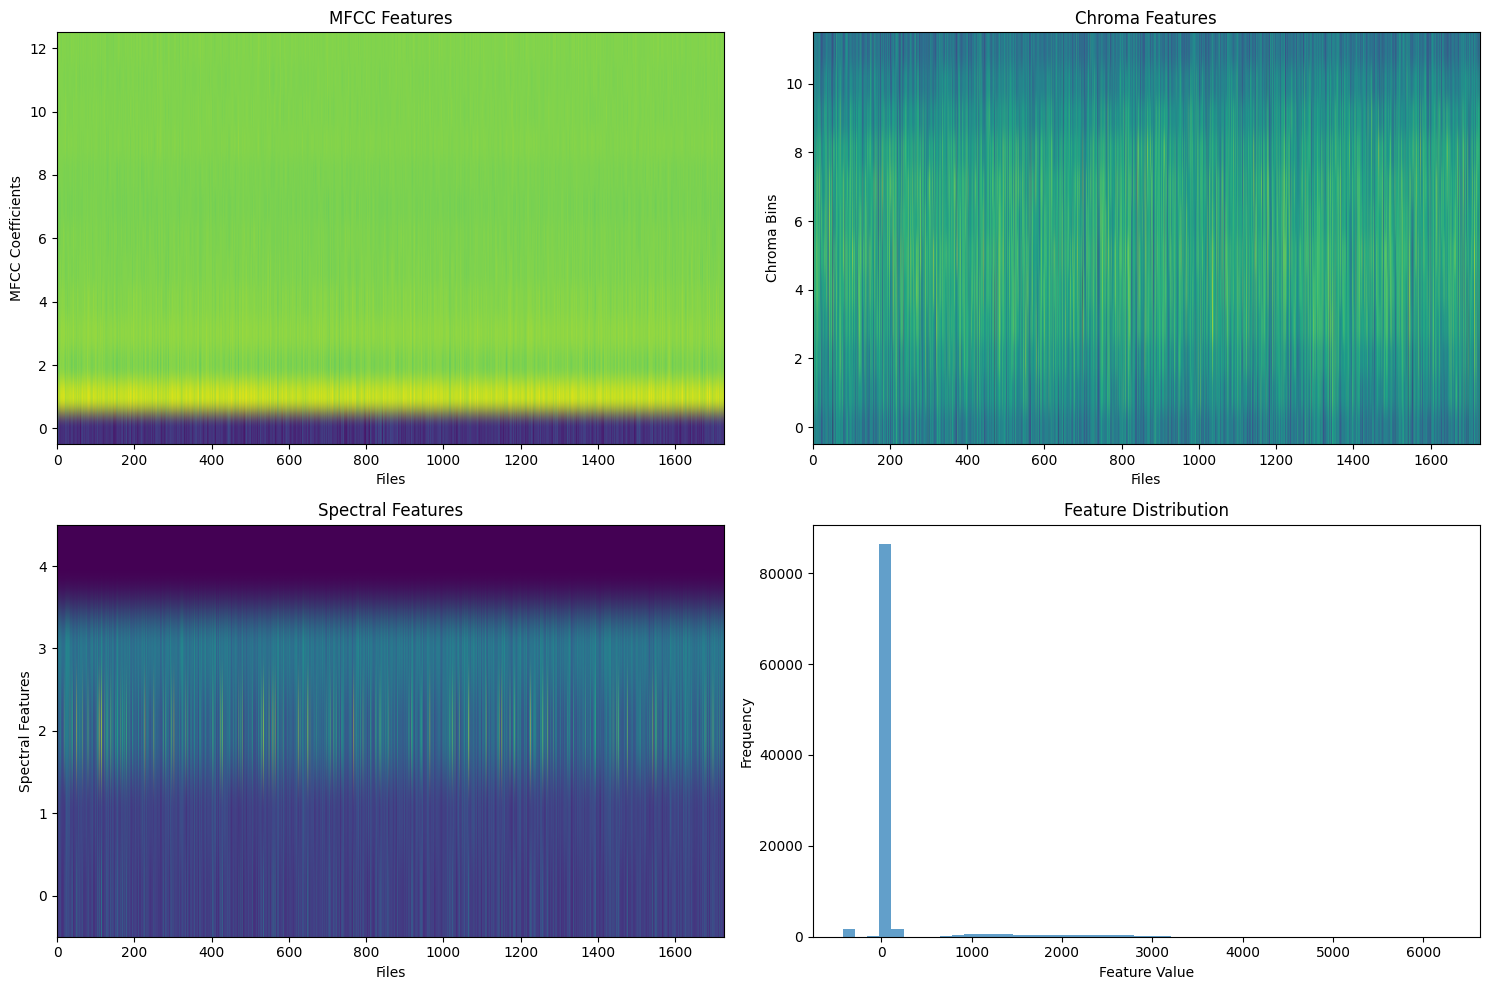

In [23]:
# Create feature visualization
if len(ravdess_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # MFCC features
    mfcc_data = ravdess_features[:, :13]  # First 13 are MFCC means
    axes[0, 0].imshow(mfcc_data.T, aspect="auto", origin="lower")
    axes[0, 0].set_title("MFCC Features")
    axes[0, 0].set_xlabel("Files")
    axes[0, 0].set_ylabel("MFCC Coefficients")

    # Chroma features
    chroma_data = ravdess_features[:, 26:38]  # Chroma means
    axes[0, 1].imshow(chroma_data.T, aspect="auto", origin="lower")
    axes[0, 1].set_title("Chroma Features")
    axes[0, 1].set_xlabel("Files")
    axes[0, 1].set_ylabel("Chroma Bins")

    # Spectral features
    spectral_data = ravdess_features[:, 50:55]  # Spectral features
    axes[1, 0].imshow(spectral_data.T, aspect="auto", origin="lower")
    axes[1, 0].set_title("Spectral Features")
    axes[1, 0].set_xlabel("Files")
    axes[1, 0].set_ylabel("Spectral Features")

    # Feature distribution
    axes[1, 1].hist(ravdess_features.flatten(), bins=50, alpha=0.7)
    axes[1, 1].set_title("Feature Distribution")
    axes[1, 1].set_xlabel("Feature Value")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [24]:
def save_features(features, labels, file_paths, filename):
    """Save extracted features to file"""
    feature_data = {
        'filepath': file_paths,
        'emotion': labels,
        'features': [features[i].tolist() for i in range(len(features))]
    }
    
    df = pd.DataFrame(feature_data)
    df.to_csv(filename, index=False)
    print(f"Features saved to {filename}")

# Save features
if len(ravdess_features) > 0:
    save_features(ravdess_features, ravdess_labels, ravdess_paths, 'ravdess_features.csv')

if len(emodb_features) > 0:
    save_features(emodb_features, emodb_labels, emodb_paths, 'emodb_features.csv')

Features saved to ravdess_features.csv
Features saved to emodb_features.csv


## Feature statistics

In [25]:
# Analyze feature statistics
if len(ravdess_features) > 0:
    print("\n=== RAVDESS Feature Statistics ===")
    print(f"Feature vector shape: {ravdess_features.shape}")
    print(f"Number of features: {ravdess_features.shape[1]}")
    print(
        f"Feature range: [{np.min(ravdess_features):.3f}, {np.max(ravdess_features):.3f}]"
    )
    print(f"Feature mean: {np.mean(ravdess_features):.3f}")
    print(f"Feature std: {np.std(ravdess_features):.3f}")


# Analyze feature statistics
if len(emodb_features) > 0:
    print("\n=== EmoDB Feature Statistics ===")
    print(f"Feature vector shape: {emodb_features.shape}")
    print(f"Number of features: {emodb_features.shape[1]}")
    print(
        f"Feature range: [{np.min(emodb_features):.3f}, {np.max(emodb_features):.3f}]"
    )
    print(f"Feature mean: {np.mean(emodb_features):.3f}")
    print(f"Feature std: {np.std(emodb_features):.3f}")


=== RAVDESS Feature Statistics ===
Feature vector shape: (1728, 56)
Number of features: 56
Feature range: [-424.383, 6291.020]
Feature mean: 131.613
Feature std: 508.951

=== EmoDB Feature Statistics ===
Feature vector shape: (427, 56)
Number of features: 56
Feature range: [-326.861, 4770.203]
Feature mean: 130.257
Feature std: 506.473


# Features visualizations

In [26]:
ravdess_features = pd.read_csv("ravdess_features.csv")
emodb_features = pd.read_csv("emodb_features.csv")

print("Original data structure:")
print(ravdess_features.head())

Original data structure:
                                     filepath  emotion  \
0  processed_ravdess/03-01-03-02-02-02-04.wav        3   
1  processed_ravdess/03-01-03-02-01-01-01.wav        3   
2  processed_ravdess/03-01-07-02-01-01-24.wav        7   
3  processed_ravdess/03-01-05-01-02-02-03.wav        5   
4  processed_ravdess/03-01-06-01-01-01-20.wav        6   

                                            features  
0  [-375.1911315917969, 33.67808151245117, -18.71...  
1  [-372.4425354003906, 58.868770599365234, 1.584...  
2  [-319.07757568359375, 63.929237365722656, -3.0...  
3  [-284.1884460449219, 65.87357330322266, -3.924...  
4  [-346.8747253417969, 34.72938919067383, 0.8120...  


## Convert Features to Proper Format

In [27]:
def convert_features_to_array(df):
    """Convert string features to numpy arrays"""
    df_converted = df.copy()

    # Convert features from string to list, then to numpy array
    df_converted["features_array"] = df_converted["features"].apply(
        lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x
    )

    return df_converted


# Convert both datasets
ravdess_converted = convert_features_to_array(ravdess_features)
emodb_converted = convert_features_to_array(emodb_features)

print("Converted data structure:")
print(f"RAVDESS features shape: {ravdess_converted['features_array'].iloc[0].shape}")
print(f"EmoDB features shape: {emodb_converted['features_array'].iloc[0].shape}")

Converted data structure:
RAVDESS features shape: (56,)
EmoDB features shape: (56,)


## Create Feature DataFrame

In [28]:
def create_feature_dataframe(df, dataset_name):
    """Create proper feature DataFrame"""
    # Extract features into separate columns
    features_list = []
    for features in df["features_array"]:
        features_list.append(features)

    # Create DataFrame with features
    feature_df = pd.DataFrame(features_list)
    feature_df.columns = [f"feature_{i}" for i in range(feature_df.shape[1])]

    # Add emotion and filepath
    feature_df["emotion"] = df["emotion"].values
    feature_df["filepath"] = df["filepath"].values
    feature_df["dataset"] = dataset_name

    return feature_df


# Create feature DataFrames
ravdess_feature_df = create_feature_dataframe(ravdess_converted, "RAVDESS")
emodb_feature_df = create_feature_dataframe(emodb_converted, "EmoDB")

print(f"RAVDESS feature DataFrame shape: {ravdess_feature_df.shape}")
print(f"EmoDB feature DataFrame shape: {emodb_feature_df.shape}")
print(ravdess_feature_df.head())


RAVDESS feature DataFrame shape: (1728, 59)
EmoDB feature DataFrame shape: (427, 59)
    feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0 -375.191132  33.678082 -18.718384   7.415907  -2.537178  -6.606359   
1 -372.442535  58.868771   1.584138  13.204648   6.131709   6.149545   
2 -319.077576  63.929237  -3.026248   7.478913 -10.728442   0.179504   
3 -284.188446  65.873573  -3.924574  13.229098   7.458256   2.158575   
4 -346.874725  34.729389   0.812039  10.958661  -0.196323  -3.685389   

   feature_6  feature_7  feature_8  feature_9  ...  feature_49   feature_50  \
0  -4.570608 -11.392019   1.259713   1.040616  ...    0.313366  1477.032678   
1  -4.766023  -1.585394  -3.917474  -1.811439  ...    0.278090   830.523118   
2  -4.392156  -8.211568  -2.395768   7.681725  ...    0.273931  1071.441650   
3  -7.552969  -6.845911  -2.413608  -1.935006  ...    0.291623  1230.262454   
4  -2.854017  -5.032299   2.303893   0.845962  ...    0.262582   984.891669   

    fea

## Feature Histograms

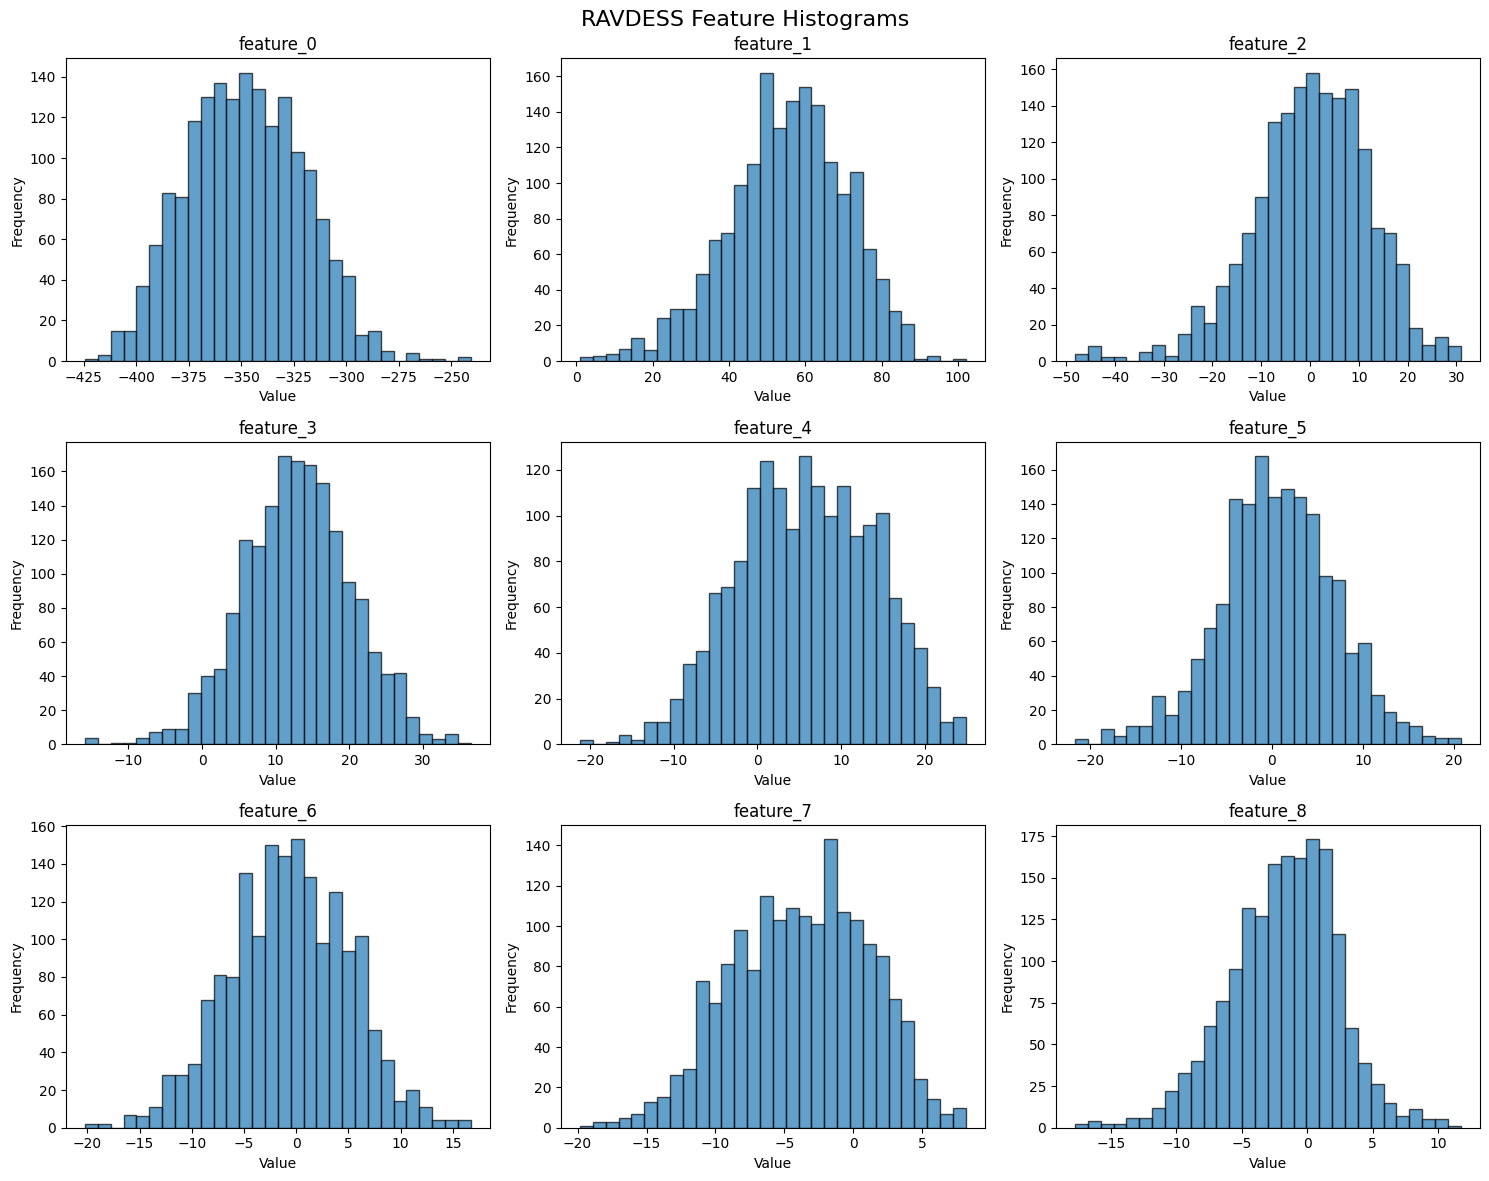

In [29]:
# Plot histograms for first 9 features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i in range(9):  # First 9 features
    col = f"feature_{i}"
    axes[i].hist(ravdess_feature_df[col], bins=30, alpha=0.7, edgecolor="black")
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("RAVDESS Feature Histograms", fontsize=16)
plt.tight_layout()
plt.show()

## Compare RAVDESS vs EmoDB

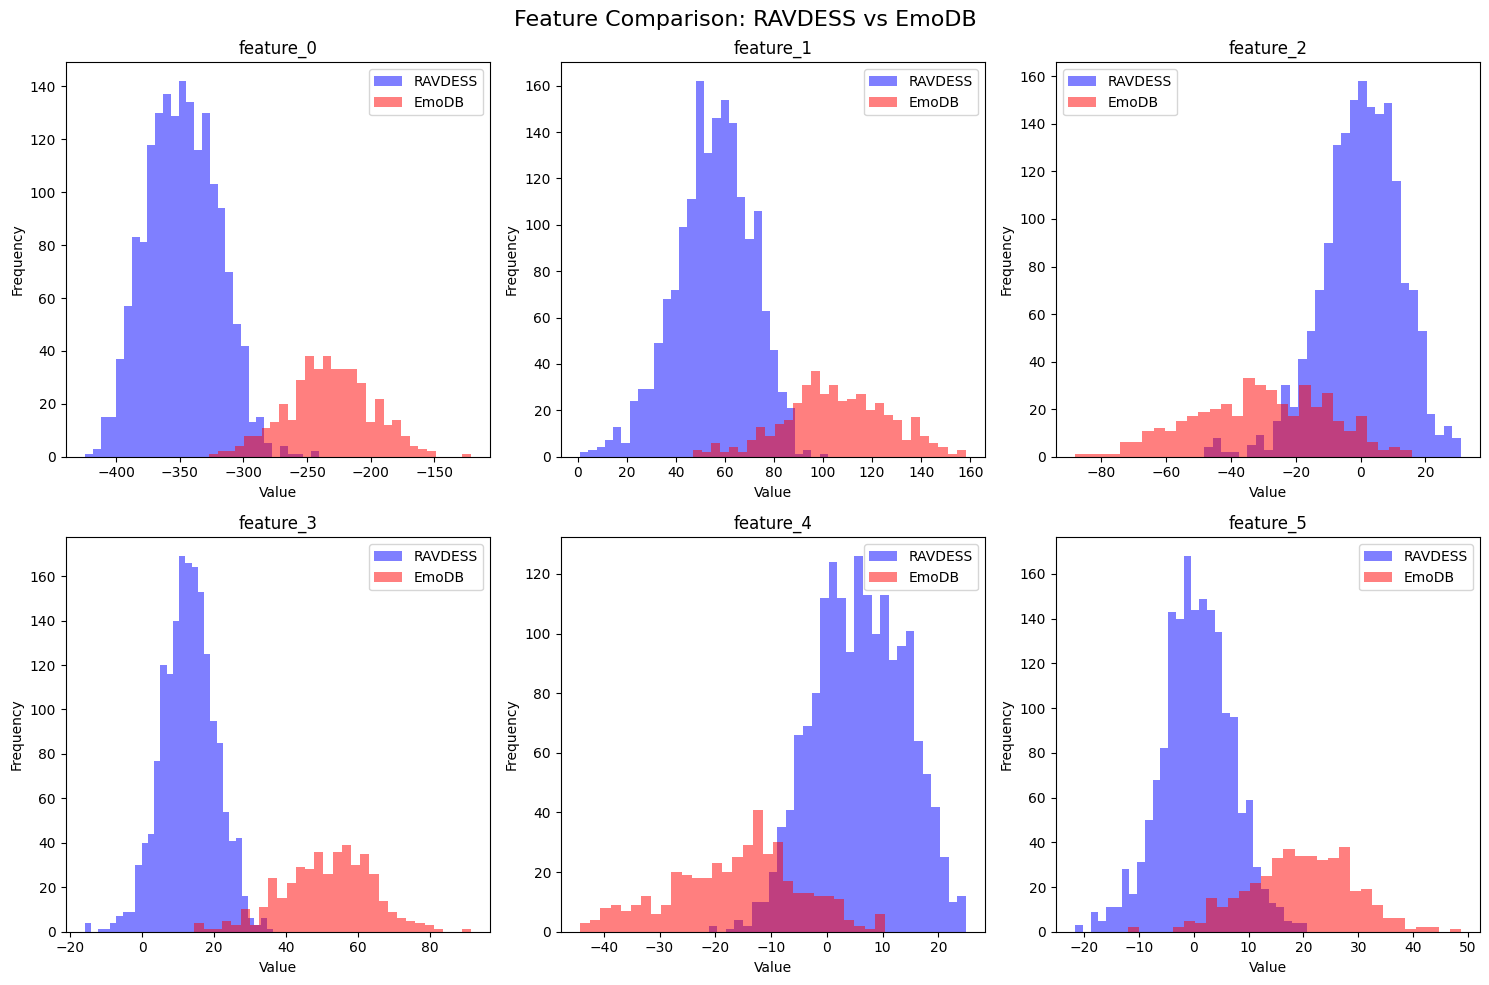

In [30]:
# Compare first 6 features between datasets
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):  # First 6 features
    col = f"feature_{i}"

    # RAVDESS
    axes[i].hist(
        ravdess_feature_df[col], bins=30, alpha=0.5, label="RAVDESS", color="blue"
    )

    # EmoDB
    axes[i].hist(emodb_feature_df[col], bins=30, alpha=0.5, label="EmoDB", color="red")

    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Feature Comparison: RAVDESS vs EmoDB", fontsize=16)
plt.tight_layout()
plt.show()

## Heatmap

In [31]:
def create_feature_matrix(df, max_samples=100):
    """Create feature matrix for heatmap"""
    # Limit samples for visualization
    df_sample = df.head(max_samples)

    # Extract features into matrix
    features_matrix = []
    for features in df_sample["features_array"]:
        features_matrix.append(features)

    return np.array(features_matrix)


# Create feature matrices
ravdess_matrix = create_feature_matrix(ravdess_converted, max_samples=50)
emodb_matrix = create_feature_matrix(emodb_converted, max_samples=50)

print(f"RAVDESS matrix shape: {ravdess_matrix.shape}")
print(f"EmoDB matrix shape: {emodb_matrix.shape}")

RAVDESS matrix shape: (50, 56)
EmoDB matrix shape: (50, 56)


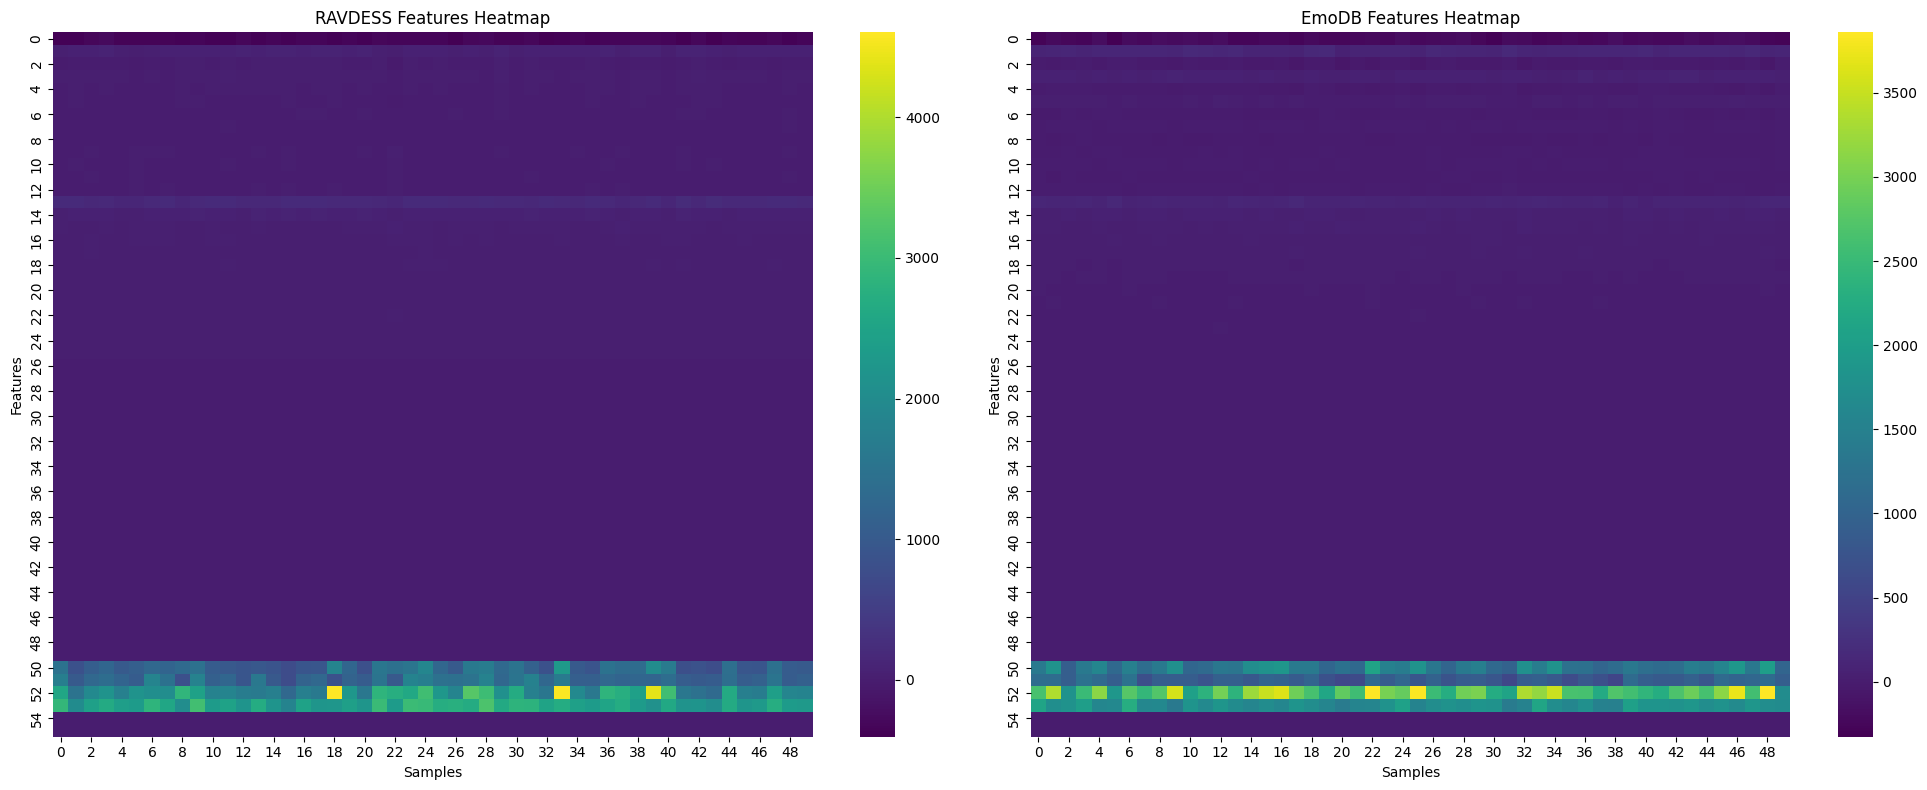

In [32]:
# Create feature heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# RAVDESS heatmap
sns.heatmap(ravdess_matrix.T, cmap="viridis", ax=axes[0], cbar=True)
axes[0].set_title("RAVDESS Features Heatmap")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Features")

# EmoDB heatmap
sns.heatmap(emodb_matrix.T, cmap="viridis", ax=axes[1], cbar=True)
axes[1].set_title("EmoDB Features Heatmap")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## Feature Correlation Heatmap

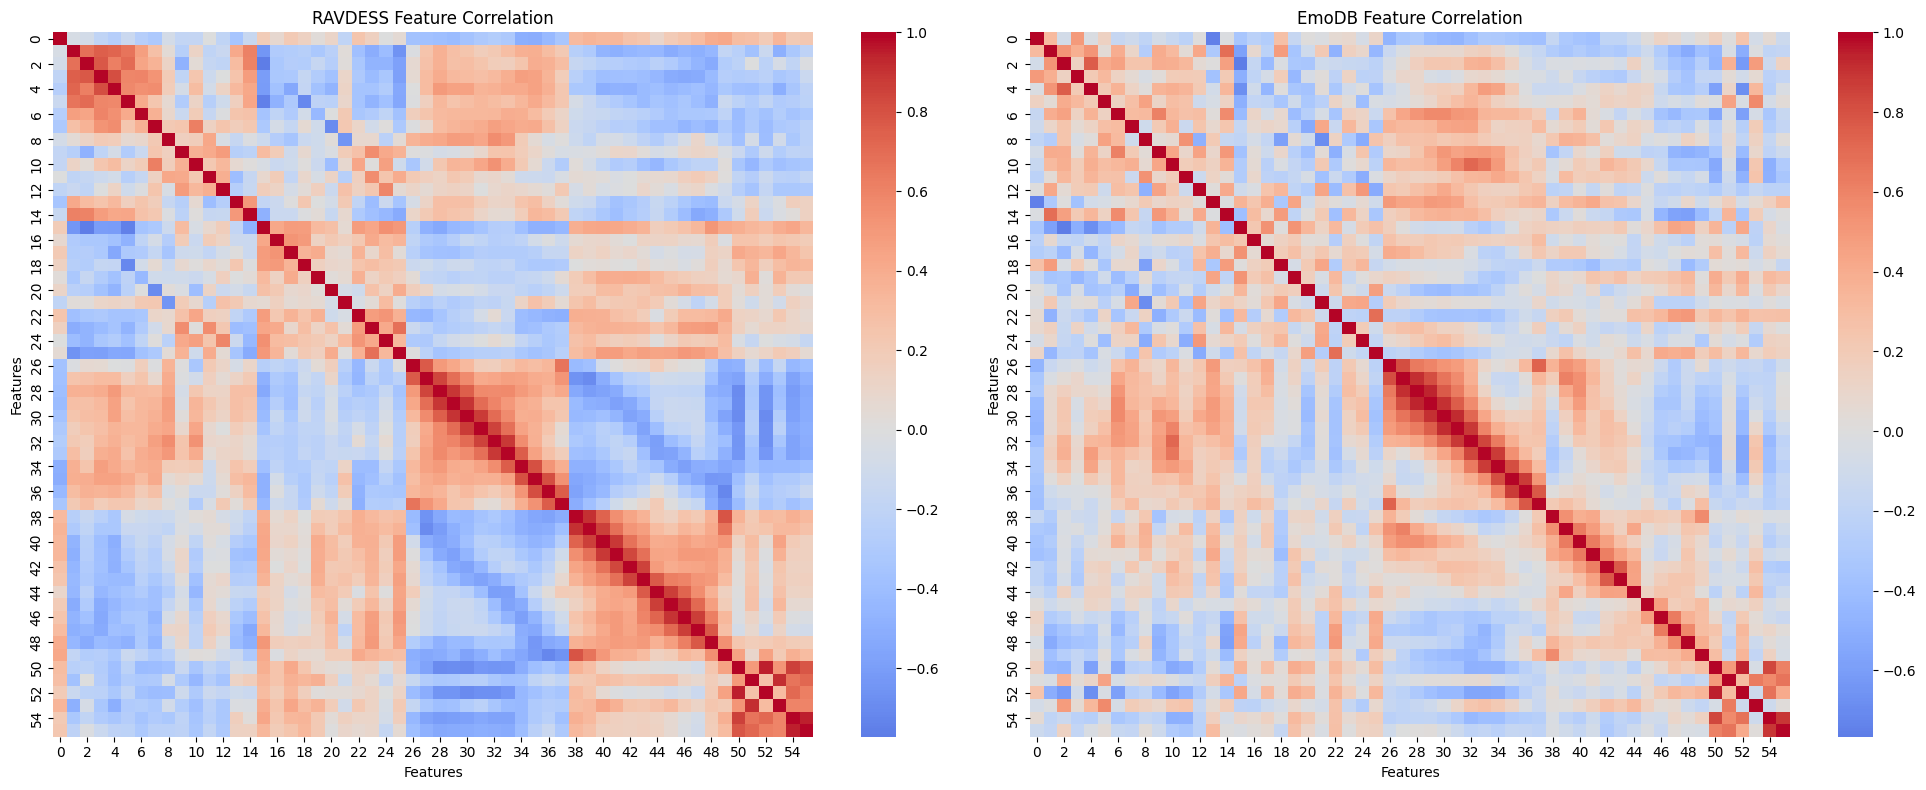

In [33]:
# Create correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# RAVDESS correlation
ravdess_corr = np.corrcoef(ravdess_matrix.T)
sns.heatmap(ravdess_corr, cmap="coolwarm", center=0, ax=axes[0], cbar=True)
axes[0].set_title("RAVDESS Feature Correlation")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Features")

# EmoDB correlation
emodb_corr = np.corrcoef(emodb_matrix.T)
sns.heatmap(emodb_corr, cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("EmoDB Feature Correlation")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

# Balance classes


=== RAVDESS Class Distribution ===
emotion
3    231
2    231
7    230
5    230
6    230
8    230
4    230
1    116
Name: count, dtype: int64

Percentages:
3: 231 (13.4%)
2: 231 (13.4%)
7: 230 (13.3%)
5: 230 (13.3%)
6: 230 (13.3%)
8: 230 (13.3%)
4: 230 (13.3%)
1: 116 (6.7%)
['1: Neutral', '2: Calm', '3: Happy', '4: Sad', '5: Angry', '6: Fearful', '7: Disgust', '8: Surprised']


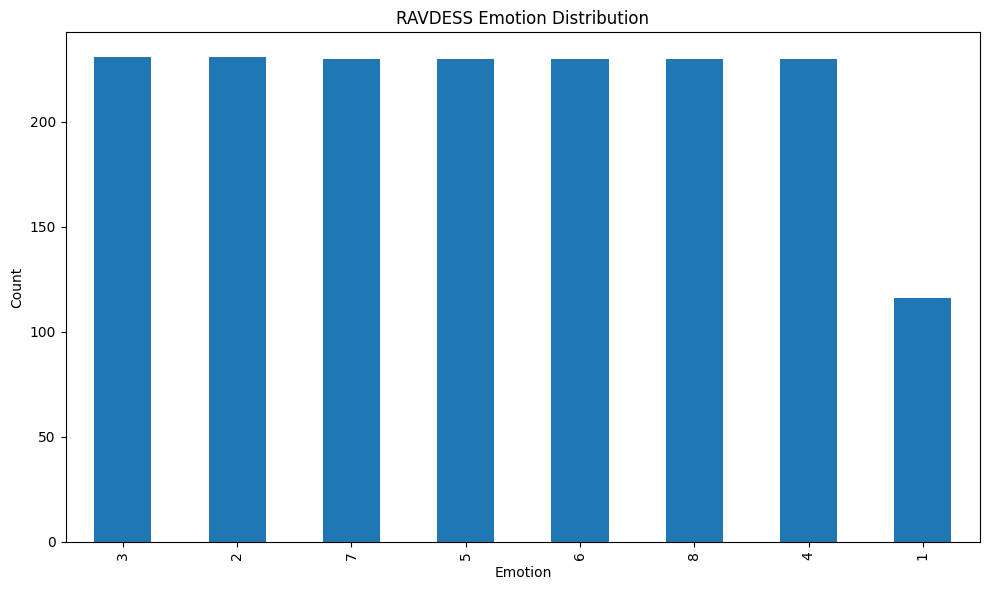


=== EmoDB Class Distribution ===
emotion
W    101
L     65
N     63
F     57
A     55
T     50
E     36
Name: count, dtype: int64

Percentages:
W: 101 (23.7%)
L: 65 (15.2%)
N: 63 (14.8%)
F: 57 (13.3%)
A: 55 (12.9%)
T: 50 (11.7%)
E: 36 (8.4%)
['W: Anger', 'L: Boredom', 'E: Disgust', 'A: Fear', 'F: Happy', 'T: Sad', 'N: Neutral']


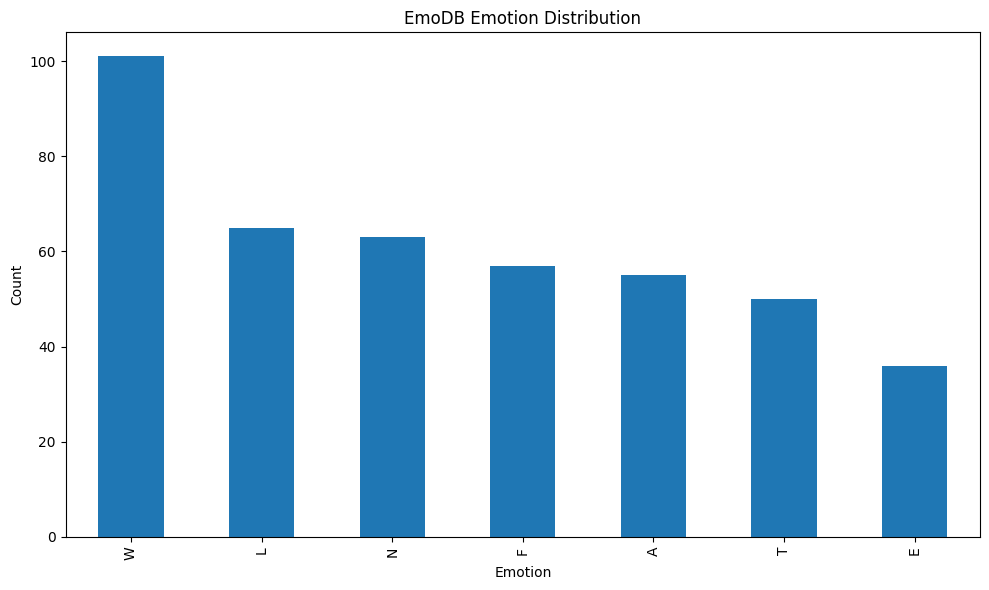

In [49]:
def analyze_class_distribution(df, dataset_name, reference_labels):
    """Analyze class distribution in dataset"""
    print(f"\n=== {dataset_name} Class Distribution ===")

    # Count emotions
    emotion_counts = df["emotion"].value_counts()
    print(emotion_counts)

    # Calculate percentages
    total = len(df)
    print(f"\nPercentages:")
    for emotion, count in emotion_counts.items():
        percentage = (count / total) * 100
        print(f"{emotion}: {count} ({percentage:.1f}%)")
    print(reference_labels)

    # Visualize distribution
    plt.figure(figsize=(10, 6))
    ax = emotion_counts.plot(kind="bar")
    plt.title(f"{dataset_name} Emotion Distribution")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return emotion_counts


# Analyze both datasets
ravdess_dist = analyze_class_distribution(
    ravdess_features, "RAVDESS", ravdess_labels_reference
)
emodb_dist = analyze_class_distribution(emodb_features, "EmoDB", emodb_labels_reference)

## Oversampling

In [55]:
def oversampling(df, target_samples=1000):
    """Simple oversampling to balance classes"""
    # Get emotion counts
    emotion_counts = df["emotion"].value_counts()

    # Find the maximum count
    max_count = max(emotion_counts.values)
    target_count = min(target_samples, max_count)

    # Oversample each emotion
    oversampled_data = []

    for emotion in emotion_counts.index:
        emotion_data = df[df["emotion"] == emotion]

        if len(emotion_data) < target_count:
            # Oversample
            oversampled = resample(
                emotion_data, n_samples=target_count, random_state=42, replace=True
            )
            oversampled_data.append(oversampled)
        else:
            # Use original data
            oversampled_data.append(emotion_data)

    # Combine all oversampled data
    balanced_df = pd.concat(oversampled_data, ignore_index=True)

    return balanced_df


# Apply simple oversampling
ravdess_balanced = oversampling(ravdess_converted, target_samples=500)
emodb_balanced = oversampling(emodb_converted, target_samples=200)

print(f"RAVDESS balanced: {len(ravdess_balanced)} samples")
print(f"EmoDB balanced: {len(emodb_balanced)} samples")

RAVDESS balanced: 1848 samples
EmoDB balanced: 707 samples


## Calculate Class Weights

In [ ]:
def calculate_class_weights(df):
    """Calculate class weights for weighted loss functions"""
    # Count emotions
    emotion_counts = df["emotion"].value_counts()

    # Calculate weights (inverse of frequency)
    total_samples = len(df)
    num_classes = len(emotion_counts)

    weights = {}
    for emotion, count in emotion_counts.items():
        weight = total_samples / (num_classes * count)
        weights[emotion] = weight

    return weights


# Calculate weights for both datasets
ravdess_weights = calculate_class_weights(ravdess_converted)
emodb_weights = calculate_class_weights(emodb_converted)

print("RAVDESS class weights:")
for emotion, weight in ravdess_weights.items():
    print(f"{emotion}: {weight:.3f}")

print("\nEmoDB class weights:")
for emotion, weight in emodb_weights.items():
    print(f"{emotion}: {weight:.3f}")

RAVDESS class weights:
3: 0.935
2: 0.935
7: 0.939
5: 0.939
6: 0.939
8: 0.939
4: 0.939
1: 1.862

EmoDB class weights:
W: 0.604
L: 0.938
N: 0.968
F: 1.070
A: 1.109
T: 1.220
E: 1.694


## Save Balanced Datasets

In [62]:
def save_balanced_dataset(df, filename):
    """Save balanced dataset to CSV"""
    # Convert features back to string format for CSV
    df_save = df.copy()
    df_save['features'] = df_save['features_array'].apply(lambda x: x.tolist())
    df_save = df_save.drop('features_array', axis=1)
    
    # Save to CSV
    df_save.to_csv(filename, index=False)
    print(f"Balanced dataset saved to {filename}")

# Save balanced datasets
save_balanced_dataset(ravdess_balanced, 'ravdess_balanced.csv')
save_balanced_dataset(emodb_balanced, 'emodb_balanced.csv')

Balanced dataset saved to ravdess_balanced.csv
Balanced dataset saved to emodb_balanced.csv


In [59]:
def create_weighted_loss_function(class_weights):
    """Create weighted loss function for neural networks"""
    import tensorflow as tf

    def weighted_categorical_crossentropy(y_true, y_pred):
        # Convert class weights to tensor
        weight_tensor = tf.constant(
            [class_weights.get(f"class_{i}", 1.0) for i in range(len(class_weights))]
        )

        # Calculate weighted loss
        loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        weights = tf.gather(weight_tensor, tf.argmax(y_true, axis=1))

        return loss * weights

    return weighted_categorical_crossentropy


# Create weighted loss functions
ravdess_weighted_loss = create_weighted_loss_function(ravdess_weights)
emodb_weighted_loss = create_weighted_loss_function(emodb_weights)

print("Weighted loss functions created")

Weighted loss functions created


# Create feature-label mappings for model input

In [74]:
ravdess_balanced = pd.read_csv('ravdess_balanced.csv')
emodb_balanced = pd.read_csv('emodb_balanced.csv')

print(f"RAVDESS balanced: {len(ravdess_balanced)} samples")
print(f"EmoDB balanced: {len(emodb_balanced)} samples")

# Convert both datasets
ravdess_converted = convert_features_to_array(ravdess_balanced)
emodb_converted = convert_features_to_array(emodb_balanced)

print("Features converted to arrays")

RAVDESS balanced: 1848 samples
EmoDB balanced: 707 samples
Features converted to arrays


## Create Feature-Label Mappings

In [91]:
def create_feature_label_mappings(df, dataset_name):
    """Create feature-label mappings for model input"""

    # Extract features and labels
    features_list = []
    labels = []

    for _, row in df.iterrows():
        features_list.append(row["features_array"])
        labels.append(row["emotion"])

    # Convert to numpy arrays
    X = np.array(features_list)
    y = np.array(labels)

    le = LabelEncoder()
    y = le.fit_transform(y)

    print(f"\n=== {dataset_name} Feature-Label Mappings ===")
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Unique labels: {le.classes_}")
    print(f"Label distribution: {np.bincount(y)}")
    print(f"Encoded labels: {np.unique(y)}")
    print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

    return X, y, le


# Create mappings for both datasets
ravdess_X, ravdess_y, ravdess_le = create_feature_label_mappings(
    ravdess_converted, "RAVDESS"
)
emodb_X, emodb_y, emodb_le = create_feature_label_mappings(
    emodb_converted, "EmoDB"
)


=== RAVDESS Feature-Label Mappings ===
Features shape: (1848, 56)
Labels shape: (1848,)
Unique labels: [1 2 3 4 5 6 7 8]
Label distribution: [231 231 231 231 231 231 231 231]
Encoded labels: [0 1 2 3 4 5 6 7]
Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3), np.int64(5): np.int64(4), np.int64(6): np.int64(5), np.int64(7): np.int64(6), np.int64(8): np.int64(7)}

=== EmoDB Feature-Label Mappings ===
Features shape: (707, 56)
Labels shape: (707,)
Unique labels: ['A' 'E' 'F' 'L' 'N' 'T' 'W']
Label distribution: [101 101 101 101 101 101 101]
Encoded labels: [0 1 2 3 4 5 6]
Label mapping: {np.str_('A'): np.int64(0), np.str_('E'): np.int64(1), np.str_('F'): np.int64(2), np.str_('L'): np.int64(3), np.str_('N'): np.int64(4), np.str_('T'): np.int64(5), np.str_('W'): np.int64(6)}


## Scale Features

In [85]:
def scale_features(X, dataset_name):
    """Scale features using StandardScaler"""

    # Create scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"\n=== {dataset_name} Feature Scaling ===")
    print(f"Original features range: [{np.min(X):.3f}, {np.max(X):.3f}]")
    print(f"Scaled features range: [{np.min(X_scaled):.3f}, {np.max(X_scaled):.3f}]")
    print(f"Scaled features mean: {np.mean(X_scaled):.3f}")
    print(f"Scaled features std: {np.std(X_scaled):.3f}")

    return X_scaled, scaler


# Scale features for both datasets
ravdess_X_scaled, ravdess_scaler = scale_features(ravdess_X, "RAVDESS")
emodb_X_scaled, emodb_scaler = scale_features(emodb_X, "EmoDB")


=== RAVDESS Feature Scaling ===
Original features range: [-424.383, 6291.020]
Scaled features range: [-5.500, 7.234]
Scaled features mean: -0.000
Scaled features std: 1.000

=== EmoDB Feature Scaling ===
Original features range: [-326.861, 4770.203]
Scaled features range: [-4.526, 4.375]
Scaled features mean: 0.000
Scaled features std: 1.000


## Create Splits

In [97]:
def create_splits(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """Create train-validation-test splits"""

    # First split: train+val vs test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Second split: train vs val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size / (1 - test_size),
        random_state=random_state,
        stratify=y_train_val,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# Create splits for RAVDESS
(
    ravdess_X_train,
    ravdess_X_val,
    ravdess_X_test,
    ravdess_y_train,
    ravdess_y_val,
    ravdess_y_test,
) = create_splits(ravdess_X_scaled, ravdess_y)

# Create splits for EmoDB
emodb_X_train, emodb_X_val, emodb_X_test, emodb_y_train, emodb_y_val, emodb_y_test = (
    create_splits(emodb_X_scaled, emodb_y, test_size=0.1, val_size=0.1)
)

print(f"\n=== Dataset Splits ===")
print(
    f"RAVDESS - Train: {ravdess_X_train.shape[0]}, Val: {ravdess_X_val.shape[0]}, Test: {ravdess_X_test.shape[0]}"
)
print(
    f"EmoDB - Train: {emodb_X_train.shape[0]}, Val: {emodb_X_val.shape[0]}, Test: {emodb_X_test.shape[0]}"
)


=== Dataset Splits ===
RAVDESS - Train: 1108, Val: 370, Test: 370
EmoDB - Train: 565, Val: 71, Test: 71


## Save Mappings

In [98]:
def save_mappings(X_train, X_val, X_test, y_train, y_val, y_test, dataset_name):
    """Save feature-label mappings to files"""
    
    # Save features
    np.save(f'{dataset_name}_X_train.npy', X_train)
    np.save(f'{dataset_name}_X_val.npy', X_val)
    np.save(f'{dataset_name}_X_test.npy', X_test)
    
    # Save labels
    np.save(f'{dataset_name}_y_train.npy', y_train)
    np.save(f'{dataset_name}_y_val.npy', y_val)
    np.save(f'{dataset_name}_y_test.npy', y_test)
    
    print(f"{dataset_name} mappings saved to .npy files")

# Save mappings for all datasets
save_mappings(ravdess_X_train, ravdess_X_val, ravdess_X_test, ravdess_y_train, ravdess_y_val, ravdess_y_test, 'ravdess')
save_mappings(emodb_X_train, emodb_X_val, emodb_X_test, emodb_y_train, emodb_y_val, emodb_y_test, 'emodb')

ravdess mappings saved to .npy files
emodb mappings saved to .npy files


# Implement a sequential model with dense layers

In [99]:
X_train = np.load("ravdess_X_train.npy")
X_val = np.load("ravdess_X_val.npy")
X_test = np.load("ravdess_X_test.npy")
y_train = np.load("ravdess_y_train.npy")
y_val = np.load("ravdess_y_val.npy")
y_test = np.load("ravdess_y_test.npy")


print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training data shape: (1108, 56)
Validation data shape: (370, 56)
Test data shape: (370, 56)
Number of classes: 8


## Convert Labels to Categorical

In [103]:
# Convert labels to categorical for multi-class classification
num_classes = len(np.unique(y_train))
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Training labels shape: {y_train_cat.shape}")
print(f"Validation labels shape: {y_val_cat.shape}")
print(f"Test labels shape: {y_test_cat.shape}")

Training labels shape: (1108, 8)
Validation labels shape: (370, 8)
Test labels shape: (370, 8)


## Create model

In [ ]:
def create_model(input_shape, num_classes):
    """Create a simple sequential model with dense layers"""

    model = keras.Sequential(
        [
            # Input layer
            layers.Dense(256, activation="relu", input_shape=(input_shape,)),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            # Hidden layers
            layers.Dense(128, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(64, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(32, activation="relu"),
            layers.Dropout(0.1),
            # Output layer
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    return model


# Create model
input_shape = X_train.shape[1]
model = create_model(input_shape, num_classes)

# Display model architecture
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,896 (69.91 KB)

 Trainable params: 17,896 (69.91 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [ ]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled successfully!")

Model compiled successfully!


## Train the Model

In [ ]:
# Define callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=0.0001
    ),
]

# Train the model
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

print("Training completed!")

## Evaluate Model

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

## Plot Training History

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Save Models

In [ ]:
# Save models
model.save("emotion_model.h5")

print("Models saved successfully!")